In [36]:
# ML Classification & Clustering: Fraud Detection & Customer Segmentation
#1. Import Libraries 

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    classification_report, confusion_matrix,
    precision_score, recall_score, f1_score,
    roc_auc_score, roc_curve
)

from imblearn.over_sampling import SMOTE
from xgboost import XGBClassifier

from sklearn.cluster import KMeans, AgglomerativeClustering
from sklearn.metrics import silhouette_score

In [ ]:
#PROJECT A — FRAUD DETECTION
#2. Load Dataset

In [2]:
df = pd.read_csv("creditcard.csv")

print(df.shape)
print(df.head())
print(df['Class'].value_counts())

(284807, 31)
   Time        V1        V2        V3        V4        V5        V6        V7  \
0   0.0 -1.359807 -0.072781  2.536347  1.378155 -0.338321  0.462388  0.239599   
1   0.0  1.191857  0.266151  0.166480  0.448154  0.060018 -0.082361 -0.078803   
2   1.0 -1.358354 -1.340163  1.773209  0.379780 -0.503198  1.800499  0.791461   
3   1.0 -0.966272 -0.185226  1.792993 -0.863291 -0.010309  1.247203  0.237609   
4   2.0 -1.158233  0.877737  1.548718  0.403034 -0.407193  0.095921  0.592941   

         V8        V9  ...       V21       V22       V23       V24       V25  \
0  0.098698  0.363787  ... -0.018307  0.277838 -0.110474  0.066928  0.128539   
1  0.085102 -0.255425  ... -0.225775 -0.638672  0.101288 -0.339846  0.167170   
2  0.247676 -1.514654  ...  0.247998  0.771679  0.909412 -0.689281 -0.327642   
3  0.377436 -1.387024  ... -0.108300  0.005274 -0.190321 -1.175575  0.647376   
4 -0.270533  0.817739  ... -0.009431  0.798278 -0.137458  0.141267 -0.206010   

        V26       V

In [37]:
#3. Check Missing Values

In [3]:
print(df.isnull().sum().sum())
print(df.info())

0
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 284807 entries, 0 to 284806
Data columns (total 31 columns):
 #   Column  Non-Null Count   Dtype  
---  ------  --------------   -----  
 0   Time    284807 non-null  float64
 1   V1      284807 non-null  float64
 2   V2      284807 non-null  float64
 3   V3      284807 non-null  float64
 4   V4      284807 non-null  float64
 5   V5      284807 non-null  float64
 6   V6      284807 non-null  float64
 7   V7      284807 non-null  float64
 8   V8      284807 non-null  float64
 9   V9      284807 non-null  float64
 10  V10     284807 non-null  float64
 11  V11     284807 non-null  float64
 12  V12     284807 non-null  float64
 13  V13     284807 non-null  float64
 14  V14     284807 non-null  float64
 15  V15     284807 non-null  float64
 16  V16     284807 non-null  float64
 17  V17     284807 non-null  float64
 18  V18     284807 non-null  float64
 19  V19     284807 non-null  float64
 20  V20     284807 non-null  float64
 21  V21     

In [38]:
#4. Visualize Class Imbalance

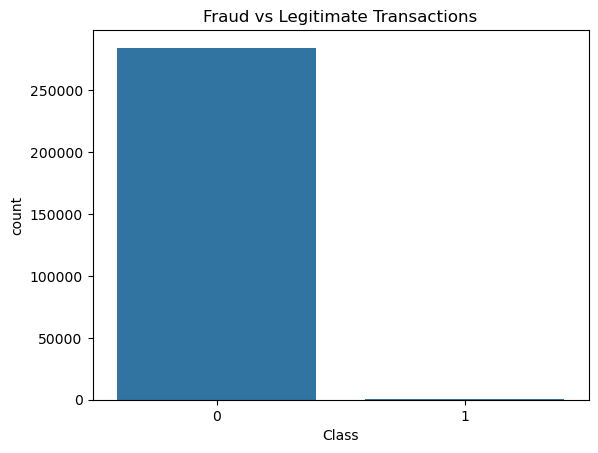

In [4]:
sns.countplot(x='Class', data=df)
plt.title("Fraud vs Legitimate Transactions")
plt.show()

In [39]:
#5. Prepare Features and Target

In [5]:
X = df.drop('Class', axis=1)
y = df['Class']

In [40]:
#6. Train-Test Split

#Use stratification so the fraud ratio is preserved

In [6]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

In [41]:
#7. Feature Scaling

In [7]:
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [42]:
#8. Handle Imbalance Using SMOTE

#Apply SMOTE only to training data.

In [8]:
smote = SMOTE(random_state=42)

X_train_smote, y_train_smote = smote.fit_resample(
    X_train_scaled, y_train
)

print(y_train_smote.value_counts())

Class
0    227451
1    227451
Name: count, dtype: int64


In [43]:
#9. Logistic Regression

In [9]:
lr = LogisticRegression(max_iter=1000)

lr.fit(X_train_smote, y_train_smote)

lr_pred = lr.predict(X_test_scaled)
lr_prob = lr.predict_proba(X_test_scaled)[:, 1]

print(classification_report(y_test, lr_pred))
print("ROC-AUC:", roc_auc_score(y_test, lr_prob))

              precision    recall  f1-score   support

           0       1.00      0.97      0.99     56864
           1       0.06      0.92      0.11        98

    accuracy                           0.97     56962
   macro avg       0.53      0.95      0.55     56962
weighted avg       1.00      0.97      0.99     56962

ROC-AUC: 0.9708434302252134


In [44]:
#10. Random Forest

In [10]:
rf = RandomForestClassifier(
    n_estimators=100,
    random_state=42,
    n_jobs=-1,
    class_weight='balanced'
)

rf.fit(X_train_smote, y_train_smote)

rf_pred = rf.predict(X_test_scaled)
rf_prob = rf.predict_proba(X_test_scaled)[:, 1]

print(classification_report(y_test, rf_pred))
print("ROC-AUC:", roc_auc_score(y_test, rf_prob))

              precision    recall  f1-score   support

           0       1.00      1.00      1.00     56864
           1       0.87      0.83      0.85        98

    accuracy                           1.00     56962
   macro avg       0.94      0.91      0.92     56962
weighted avg       1.00      1.00      1.00     56962

ROC-AUC: 0.9684484390970794


In [45]:
#11. XGBoost

In [11]:
xgb = XGBClassifier(
    n_estimators=100,
    max_depth=5,
    learning_rate=0.1,
    random_state=42,
    eval_metric='logloss'
)

xgb.fit(X_train_smote, y_train_smote)

xgb_pred = xgb.predict(X_test_scaled)
xgb_prob = xgb.predict_proba(X_test_scaled)[:, 1]

print(classification_report(y_test, xgb_pred))
print("ROC-AUC:", roc_auc_score(y_test, xgb_prob))

              precision    recall  f1-score   support

           0       1.00      1.00      1.00     56864
           1       0.25      0.88      0.39        98

    accuracy                           1.00     56962
   macro avg       0.63      0.94      0.69     56962
weighted avg       1.00      1.00      1.00     56962

ROC-AUC: 0.979868005868639


In [46]:
#12. Compare Models

In [12]:
results = pd.DataFrame({
    'Model': ['Logistic Regression', 'Random Forest', 'XGBoost'],
    'Precision': [
        precision_score(y_test, lr_pred),
        precision_score(y_test, rf_pred),
        precision_score(y_test, xgb_pred)
    ],
    'Recall': [
        recall_score(y_test, lr_pred),
        recall_score(y_test, rf_pred),
        recall_score(y_test, xgb_pred)
    ],
    'F1 Score': [
        f1_score(y_test, lr_pred),
        f1_score(y_test, rf_pred),
        f1_score(y_test, xgb_pred)
    ],
    'ROC-AUC': [
        roc_auc_score(y_test, lr_prob),
        roc_auc_score(y_test, rf_prob),
        roc_auc_score(y_test, xgb_prob)
    ]
})

print(results)

                 Model  Precision    Recall  F1 Score   ROC-AUC
0  Logistic Regression   0.057803  0.918367  0.108761  0.970843
1        Random Forest   0.870968  0.826531  0.848168  0.968448
2              XGBoost   0.252199  0.877551  0.391800  0.979868


In [47]:
#13. Confusion Matrix

#For the best model, for example XGBoost:

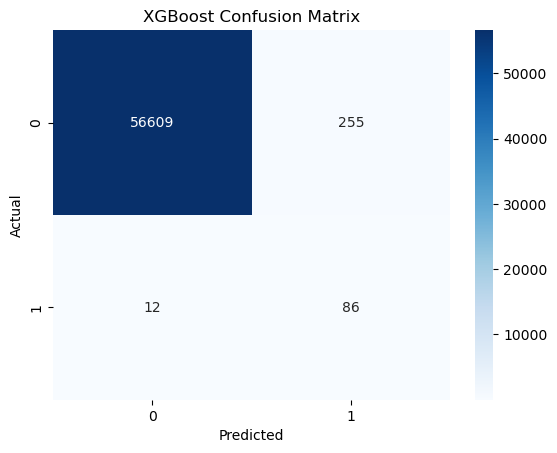

In [13]:
cm = confusion_matrix(y_test, xgb_pred)

sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("XGBoost Confusion Matrix")
plt.show()

In [48]:
#14. ROC Curve

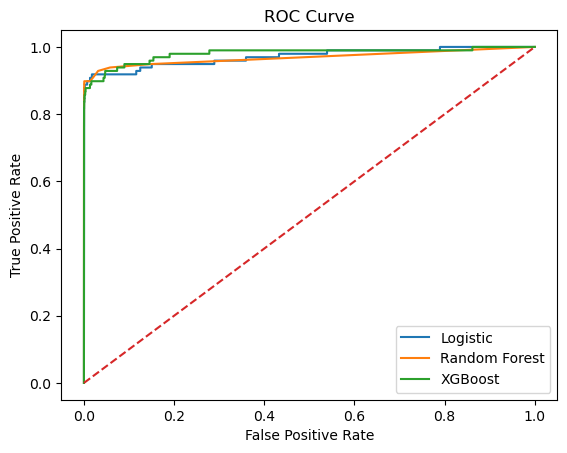

In [14]:
fpr_lr, tpr_lr, _ = roc_curve(y_test, lr_prob)
fpr_rf, tpr_rf, _ = roc_curve(y_test, rf_prob)
fpr_xgb, tpr_xgb, _ = roc_curve(y_test, xgb_prob)

plt.plot(fpr_lr, tpr_lr, label='Logistic')
plt.plot(fpr_rf, tpr_rf, label='Random Forest')
plt.plot(fpr_xgb, tpr_xgb, label='XGBoost')

plt.plot([0, 1], [0, 1], '--')
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")
plt.legend()
plt.show()

In [49]:
#15. Optimize Fraud Detection Threshold

#Default threshold is 0.5.

#For fraud detection, we may lower it to catch more fraud.

In [15]:
threshold = 0.30

custom_pred = (xgb_prob >= threshold).astype(int)

print(classification_report(y_test, custom_pred))

              precision    recall  f1-score   support

           0       1.00      0.99      0.99     56864
           1       0.12      0.88      0.21        98

    accuracy                           0.99     56962
   macro avg       0.56      0.93      0.60     56962
weighted avg       1.00      0.99      0.99     56962



In [50]:
#Try different thresholds:

In [16]:
for threshold in [0.1, 0.2, 0.3, 0.4, 0.5]:
    pred = (xgb_prob >= threshold).astype(int)

    print(
        threshold,
        "Precision:", precision_score(y_test, pred),
        "Recall:", recall_score(y_test, pred),
        "F1:", f1_score(y_test, pred)
    )

0.1 Precision: 0.035541195476575124 Recall: 0.8979591836734694 F1: 0.06837606837606838
0.2 Precision: 0.07351712614870509 Recall: 0.8979591836734694 F1: 0.13590733590733592
0.3 Precision: 0.11621621621621622 Recall: 0.8775510204081632 F1: 0.2052505966587112
0.4 Precision: 0.1787941787941788 Recall: 0.8775510204081632 F1: 0.2970639032815199
0.5 Precision: 0.25219941348973607 Recall: 0.8775510204081632 F1: 0.3917995444191344


In [17]:
#PROJECT B — CUSTOMER SEGMENTATION

In [51]:
#16. Load Mall Customers

In [20]:
customers = pd.read_csv(
    "Mall_Customers.csv"
)

print(customers.head())
print(customers.info())

   CustomerID  Gender  Age  Annual Income (k$)  Spending Score (1-100)
0           1    Male   19                  15                      39
1           2    Male   21                  15                      81
2           3  Female   20                  16                       6
3           4  Female   23                  16                      77
4           5  Female   31                  17                      40
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 200 entries, 0 to 199
Data columns (total 5 columns):
 #   Column                  Non-Null Count  Dtype 
---  ------                  --------------  ----- 
 0   CustomerID              200 non-null    int64 
 1   Gender                  200 non-null    object
 2   Age                     200 non-null    int64 
 3   Annual Income (k$)      200 non-null    int64 
 4   Spending Score (1-100)  200 non-null    int64 
dtypes: int64(4), object(1)
memory usage: 7.9+ KB
None


In [52]:
#17. Select Clustering Features

#Use:

#Age
#Annual Income
#Spending Score

In [21]:
features = [
    'Age',
    'Annual Income (k$)',
    'Spending Score (1-100)'
]

X_customer = customers[features]

In [53]:
#18. Scale Features

In [22]:
scaler = StandardScaler()

X_customer_scaled = scaler.fit_transform(X_customer)

In [54]:
#19. Find Optimal K Using Elbow Method

C:\Users\MANJUNATH\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(
C:\Users\MANJUNATH\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(
C:\Users\MANJUNATH\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(
C:\Users\MANJUNATH\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memor

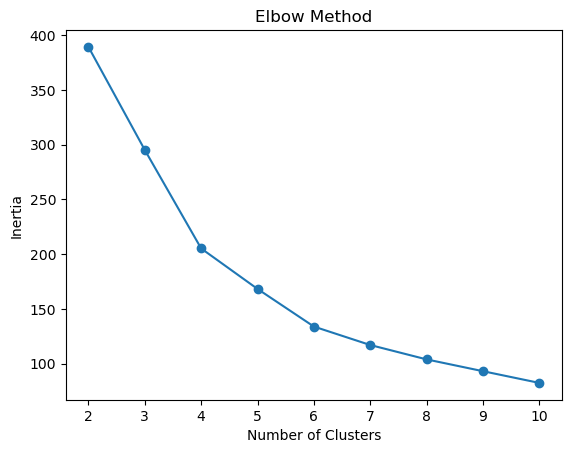

In [23]:
inertia = []

for k in range(2, 11):
    kmeans = KMeans(
        n_clusters=k,
        random_state=42,
        n_init=10
    )

    kmeans.fit(X_customer_scaled)
    inertia.append(kmeans.inertia_)

plt.plot(range(2, 11), inertia, marker='o')
plt.xlabel("Number of Clusters")
plt.ylabel("Inertia")
plt.title("Elbow Method")
plt.show()

In [55]:
#20. K-Means Clustering

In [24]:
kmeans = KMeans(
    n_clusters=5,
    random_state=42,
    n_init=10
)

customers['Cluster'] = kmeans.fit_predict(
    X_customer_scaled
)

print(customers.head())

   CustomerID  Gender  Age  Annual Income (k$)  Spending Score (1-100)  \
0           1    Male   19                  15                      39   
1           2    Male   21                  15                      81   
2           3  Female   20                  16                       6   
3           4  Female   23                  16                      77   
4           5  Female   31                  17                      40   

   Cluster  
0        1  
1        1  
2        0  
3        1  
4        1  


C:\Users\MANJUNATH\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(


In [56]:
#21. Silhouette Score

In [25]:
score = silhouette_score(
    X_customer_scaled,
    customers['Cluster']
)

print("Silhouette Score:", score)

Silhouette Score: 0.41664341513732767


In [57]:
#22. Visualize Customer Segments

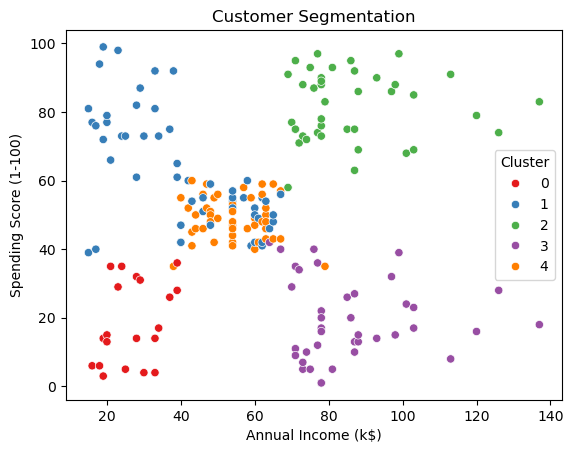

In [26]:
sns.scatterplot(
    data=customers,
    x='Annual Income (k$)',
    y='Spending Score (1-100)',
    hue='Cluster',
    palette='Set1'
)

plt.title("Customer Segmentation")
plt.show()

In [58]:
#23. Analyze Each Cluster

In [27]:
cluster_summary = customers.groupby('Cluster')[
    ['Age', 'Annual Income (k$)', 'Spending Score (1-100)']
].mean()

print(cluster_summary)

               Age  Annual Income (k$)  Spending Score (1-100)
Cluster                                                       
0        46.250000           26.750000               18.350000
1        25.185185           41.092593               62.240741
2        32.875000           86.100000               81.525000
3        39.871795           86.102564               19.358974
4        55.638298           54.382979               48.851064


In [59]:
#24. Hierarchical Clustering

In [28]:
hc = AgglomerativeClustering(
    n_clusters=5
)

customers['HC_Cluster'] = hc.fit_predict(
    X_customer_scaled
)

print(customers['HC_Cluster'].value_counts())

HC_Cluster
0    66
1    45
2    39
3    28
4    22
Name: count, dtype: int64


In [60]:
#25. Hierarchical Cluster Visualization

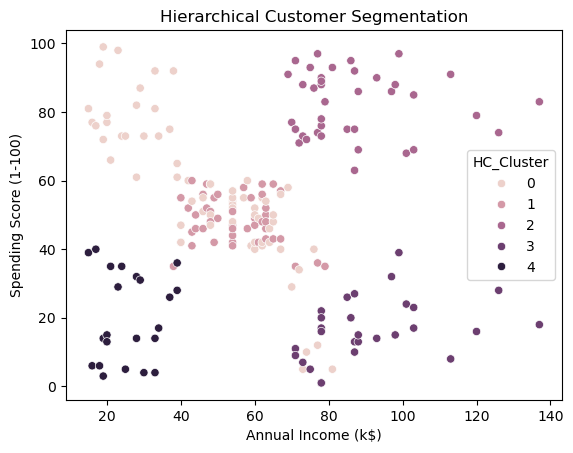

In [29]:
sns.scatterplot(
    data=customers,
    x='Annual Income (k$)',
    y='Spending Score (1-100)',
    hue='HC_Cluster'
)

plt.title("Hierarchical Customer Segmentation")
plt.show()

In [61]:
#26. Customer Segment Interpretation

#Use the cluster averages:

In [30]:
print(
    customers.groupby('Cluster')[
        ['Age',
         'Annual Income (k$)',
         'Spending Score (1-100)']
    ].mean()
)

               Age  Annual Income (k$)  Spending Score (1-100)
Cluster                                                       
0        46.250000           26.750000               18.350000
1        25.185185           41.092593               62.240741
2        32.875000           86.100000               81.525000
3        39.871795           86.102564               19.358974
4        55.638298           54.382979               48.851064


In [62]:
#27. Final Fraud Detection Insights

In [31]:
print(results.sort_values('F1 Score', ascending=False))

                 Model  Precision    Recall  F1 Score   ROC-AUC
1        Random Forest   0.870968  0.826531  0.848168  0.968448
2              XGBoost   0.252199  0.877551  0.391800  0.979868
0  Logistic Regression   0.057803  0.918367  0.108761  0.970843


In [63]:
#28. Final Customer Segmentation Insights

In [32]:
print(cluster_summary)

               Age  Annual Income (k$)  Spending Score (1-100)
Cluster                                                       
0        46.250000           26.750000               18.350000
1        25.185185           41.092593               62.240741
2        32.875000           86.100000               81.525000
3        39.871795           86.102564               19.358974
4        55.638298           54.382979               48.851064


In [ ]:
#29. Save Final Dataset

In [33]:
customers.to_csv(
    "customer_segments.csv",
    index=False
)